# Project SP5 - Finite State Markov Chain: Conditional Expectation Estimation

## S4965918 - Edoardo Vassallo

**Goal:** Given a trajectory $X_1, \ldots, X_T$ from a finite-state Markov chain, estimate  
$$\hat{f}(x) \approx \mathbb{E}[X_{t+1} \mid X_t = x]$$
using two methods:
1. **Monte-Carlo conditional expectation** - empirical average of next states per starting state
2. **Kernel VAR (p=1)** - kernelized regression on $(X_t, X_{t+1})$ pairs

**Splits:** Train on $[1, 0.8T]$, tune hyper-parameters on $[0.8T, 0.9T]$, test on $[0.9T, T]$.

---


In [297]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

---
## Utilities

In [298]:
# One-hot encoding

def one_hot(x, n_states):
    """Encode a scalar state x as a one-hot vector of length n_states.
    Returns a numpy array of shape (n_states,).
    """
    v = np.zeros(n_states)
    v[x] = 1.0
    return v


def one_hot_matrix(X, n_states):
    """
    Encode a trajectory X (length T) as a matrix of one-hot vectors.
    Returns shape (T, n_states).
    """
    E = np.zeros((len(X), n_states))
    E[np.arange(len(X)), X] = 1.0
    return E


# Trajectory generation

def generate_trajectory(P, T, rng):
    """
    Generate a trajectory of length T from transition matrix P using rng.
    Returns a numpy array of shape (T,).
    """
    N = P.shape[0]
    X = np.zeros(T, dtype=int)
    X[0] = rng.integers(N)
    for t in range(1, T):
        X[t] = rng.choice(N, p=P[X[t-1]])
    return X


def split_trajectory(X, train_frac=0.8, val_frac=0.1):
    """
    Split trajectory X into train/val/test segments according to the given fractions.
    Returns three numpy arrays: (X_train, X_val, X_test).
    """
    T  = len(X)
    i1 = int(T * train_frac)
    i2 = int(T * (train_frac + val_frac))
    return X[:i1], X[i1:i2], X[i2:]


# Evaluation 

def mpe(X_segment, predict_fn):
    """
    Mean Prediction Error. predict_fn takes a scalar state index,
    returns a scalar prediction of the next state index.
    """
    inputs  = X_segment[:-1]
    targets = X_segment[1:].astype(float)
    preds   = np.array([predict_fn(x) for x in inputs])
    valid   = ~np.isnan(preds)
    if valid.sum() == 0:
        return np.nan
    return np.mean((targets[valid] - preds[valid]) ** 2)


def true_conditional_expectation(P):
    """
    E[X_{t+1} | X_t = x] = sum_j j * P[x,j] for each state x.
    """
    return P @ np.arange(P.shape[0], dtype=float)


def oracle_error(P, X_segment):
    """
    Compute the MPE of the true conditional expectation oracle on the given segment.
    """
    ce = true_conditional_expectation(P)
    return mpe(X_segment, lambda x: ce[x])

---
## Method 1 - Monte Carlo Conditional Expectation

For each state $x \in S$, the MC estimate is:
$$\hat{\mathbb{E}}[X_{t+1} \mid X_t = x] = \frac{\sum_{t\,:\,X_t = x} X_{t+1}}{\#\{t : X_t = x\}}$$

We could rewrite it as the following:

$$\hat{\mathbb{E}}[X_{t+1} \mid X_t = x] = \sum_{j}^N \frac{\#\{t : X_t = x \text{ and } X_{t+1} = j\}}{\#\{t : X_t = x\}} j = \sum_j^N \hat{P_{x, j}} \cdot j \quad \forall j \in S$$

Where $\hat{P_{x, j}}$ is the estimated transition probability of moving from state $x$ to state $j$. 

As $ T \to \infty$, $ \hat{P_{x, j}} \to P_{x, j}$ and the Montecarlo estimation moves towards the actual value 

In [299]:
class MonteCarloCE:
    """
    Monte Carlo estimator of E[X_{t+1} | X_t = x].
    Fits on a trajectory segment; predicts for any state seen during training.
    """

    def __init__(self, n_states):
        self.n_states  = n_states
        self.estimates = None  
        self.counts    = None   # how many times each state was visited

    def fit(self, X_train):
        counts = np.zeros(self.n_states)
        sums   = np.zeros(self.n_states)
        for t in range(len(X_train) - 1):
            s, s_next  = X_train[t], X_train[t + 1]
            counts[s] += 1
            sums[s]   += s_next
        self.counts    = counts
        # NaN for states never visited in training
        self.estimates = np.where(counts > 0, sums / counts, np.nan)
        return self

    def predict(self, x):
        return self.estimates[x]

    def mpe(self, X_segment):
        return mpe(X_segment, self.predict)

---
## Method 2 - Kernel VAR ($p = 1$)

We treat prediction as **kernel regression** on a autoregressive dataset.

Given $p =1$, our dataset becomes the following set of tuples.

$$\{(X_t, X_{t+1})\}_{t=1}^{T_{\text{train}}-1}$$

Each time, we try to predict the next state based on only the previous one.

We will be using a **Gaussian (RBF) kernel** 

$$k(x, x') = \exp{\!\left(-\frac{||x-x'||^2}{2\sigma^2}\right)}$$

We will compute our prediction as:

$$\hat{f}(x) = \sum_{t} \alpha_t\, k(x, X_t), \qquad
\boldsymbol{\alpha} = (K + \lambda n I)^{-1}\mathbf{y}$$

Where $K_{ts} = k(X_t, X_s)$ and $y_t = X_{t+1}$.

**Hyperparameters** ($\sigma$, $\lambda$) will be chosen by minimizing
the MPE on the **validation** set.

---

There is one important note that must be made, which is dependant on the choice of representation of our states.

Given that we want to work in a general vector case, the most logical way to represent our states is to use one-hot encoding.

With one-hot encoding, each state $x$ is mapped to $e_x \in \mathbb{R}^N$ with a 1 in position $x$ and $0$ elsewhere. The squared distance between any two distinct states is always either:

$$||e_x​−e_{x'}​||^2 = \begin{cases} 0 & x = x' \\ 2 & x \neq x' \end{cases}$$

Given the usage of the distance between states in the kernel function, we can rewrite the kernel matrix
$K \in \mathbb{R}^{n \times n}$ in the following analytical form:

$$K_{ij} = \begin{cases} 1 & X_i = X_j \\ e^{-1/\sigma^2} & X_i \neq X_j \end{cases}$$

We can see here how the $\sigma$ value controls directly the behaviour of the model. Considering $\sigma \to 0$, the kernel acts like a Kronecker's delta, and the prediction becomes:

$$ \hat{f}(x) = \sum_{i\,:\,X_i = x} \alpha_i$$

Where $\alpha_i$ is computed from:

$$ \boldsymbol{\alpha} = (I + \lambda n I)^{-1}\mathbf{y} $$
$$ \alpha_i = \frac{X_{i+1}}{1 + \lambda n}$$

By plugging it back into the previous formula we finally obtain:

$$ \hat{f}(x) = \frac{1}{1 + \lambda n} \sum_{i\,:\,X_i = x} X_{i+1}$$

This form is similar to Montecarlo's, but it differs in the denominator: Montecarlo averages by the actual visits in $x$, while VAR averages everything by a common factor, which depends on $\lambda$

If instead $ \sigma \to \infty$, The kernel becomes full of $1$ s, and the prediction becomes:

$$ \hat{f}(x) = \sum_{i}^n \alpha_i$$

Where $\alpha_i$ is computed from:

$$ \boldsymbol{\alpha} = (11^T + \lambda n I)^{-1}\mathbf{y} $$

For small values of $\lambda$, the resulting system behaves approximately as follows:

$$\hat{f}(x) \approx \frac{1}{n} \sum_{i}^n X_{i+1}$$

This is just the global mean between all states


In [300]:
class KernelVAROneHotNaive:
    """
    Kernel VAR (p=1) with RBF kernel on one-hot encoded states.
    explicitly constructs one-hot vectors and
    computes kernel distances directly from the formula.
    """

    def __init__(self, n_states, sigma=1.0, lam=1e-3):
        self.n_states = n_states
        self.sigma    = sigma
        self.lam      = lam

    def _rbf(self, ex, ey):
        """RBF kernel between two one-hot vectors, direct formula."""
        return np.exp(-np.sum((ex - ey) ** 2) / (2 * self.sigma ** 2))

    def _build_kernel_matrix(self, X_a, X_b=None):
        """Build kernel matrix by explicitly encoding states as one-hot vectors."""
        if X_b is None:
            X_b = X_a
        E_a = one_hot_matrix(X_a, self.n_states)   # shape (len(X_a), N)
        E_b = one_hot_matrix(X_b, self.n_states)   # shape (len(X_b), N)
        K   = np.zeros((len(X_a), len(X_b)))
        for i, ea in enumerate(E_a):
            for j, eb in enumerate(E_b):
                K[i, j] = self._rbf(ea, eb)
        return K

    def fit(self, X_train):
        inputs  = X_train[:-1]
        targets = X_train[1:].astype(float)
        n       = len(inputs)

        K          = self._build_kernel_matrix(inputs)
        self.alpha = np.linalg.solve(K + self.lam * n * np.eye(n), targets)
        self._train_inputs = inputs

        all_states        = np.arange(self.n_states)
        K_pred            = self._build_kernel_matrix(all_states, inputs)
        self._state_preds = K_pred @ self.alpha
        return self

    def predict(self, x):
        return self._state_preds[int(x)]

    def mpe(self, X_segment):
        return mpe(X_segment, self.predict)

In [301]:
class KernelVAROneHot:
    """
    Kernel VAR (p=1) with RBF kernel on one-hot encoded states.

    Key property: K_{ij} = 1 if X_i == X_j, else exp(-1/sigma^2).
    This two-value structure is exploited for efficiency.
    """

    def __init__(self, n_states, sigma=1.0, lam=1e-3):
        self.n_states = n_states
        self.sigma    = sigma
        self.lam      = lam

    def _build_kernel_matrix(self, X_a, X_b=None):
        """
        Build kernel matrix between two sets of (integer) states.
        Uses the analytical form: K_ij = 1 if same state, c otherwise.
        """
        if X_b is None:
            X_b = X_a
        c = np.exp(-1.0 / self.sigma**2)     # off-diagonal value
        # Start with all entries = c, then set diagonal (same-state) entries to 1
        K = np.full((len(X_a), len(X_b)), c)
        same = (X_a[:, None] == X_b[None, :])
        K[same] = 1.0
        return K

    def fit(self, X_train):
        inputs  = X_train[:-1]          # integer states, shape (n,)
        targets = X_train[1:].astype(float)  # next states, shape (n,)
        n       = len(inputs)

        K           = self._build_kernel_matrix(inputs)
        self.alpha  = np.linalg.solve(K + self.lam * n * np.eye(n), targets)
        self._train_inputs = inputs

        # Pre-compute prediction for every state (fast at eval time)
        all_states        = np.arange(self.n_states)
        K_pred            = self._build_kernel_matrix(all_states, inputs)
        self._state_preds = K_pred @ self.alpha
        return self

    def predict(self, x):
        return self._state_preds[int(x)]

    def mpe(self, X_segment):
        return mpe(X_segment, self.predict)


def tune_kernel_var_onehot(X_train, X_val, n_states, sigma_grid, lambda_grid):
    best_mpe    = np.inf
    best_params = (sigma_grid[0], lambda_grid[0])
    grid        = np.full((len(sigma_grid), len(lambda_grid)), np.nan)

    for i, sigma in enumerate(sigma_grid):
        for j, lam in enumerate(lambda_grid):
            model      = KernelVAROneHot(n_states, sigma=sigma, lam=lam)
            model.fit(X_train)
            val_mpe    = model.mpe(X_val)
            grid[i, j] = val_mpe
            if val_mpe < best_mpe:
                best_mpe    = val_mpe
                best_params = (sigma, lam)

    return best_params[0], best_params[1], best_mpe, grid


In [302]:
# Small sigma, small lambda: approaches MC estimator

sigma = 0.001   # small sigma
lam   = 1e-3
c     = np.exp(-1.0 / sigma**2)  # ≈ 0

K     = (1-c) * np.eye(n) + c * np.ones((n, n))
alpha = np.linalg.solve(K + lam * n * np.eye(n), y)

print(f'alpha_i * (1 + lam*n)= {alpha * (1 + lam*n)}')  
print(f'y_i = {y}')

alpha_i * (1 + lam*n)= [ 0.48720268 -1.11898124  0.31568699  0.08471017  0.92223331 -0.36001378
 -0.398209   -0.53211985  0.82095211 -1.81758452]
y_i = [ 0.48720268 -1.11898124  0.31568699  0.08471017  0.92223331 -0.36001378
 -0.398209   -0.53211985  0.82095211 -1.81758452]


In [303]:
# big sigma, small lambda: approaches heavy smoothing (all states similar)

n     = 10
sigma = 100.0   # large sigma
lam   = 1e-3
c     = np.exp(-1.0 / sigma**2)

# Build K = (1-c)I + c*11^T
K     = (1-c) * np.eye(n) + c * np.ones((n, n))
y     = np.random.randn(n)

# Solve for alpha
alpha = np.linalg.solve(K + lam * n * np.eye(n), y)

# Check if sum(alpha) \approx mean(y) / (lam*n)
print(f'sum(alpha)        = {alpha.sum():.6f}')
print(f'mean(y)/(1+lam)   = {y.mean()/(1+lam):.6f}')

sum(alpha)        = 0.074932
mean(y)/(1+lam)   = 0.074925


---
## Transition Matrix

In [304]:
# Transition matrix presets 

# Preset 1: Near-cycle (strong directional flow 0→1→2→3→0)
PRESET_CYCLE = np.array([
    [0.05, 0.85, 0.05, 0.05],
    [0.05, 0.05, 0.85, 0.05],
    [0.05, 0.05, 0.05, 0.85],
    [0.85, 0.05, 0.05, 0.05],
])

# Preset 2: Two clusters (states {0,1} and {2,3} rarely mix)
PRESET_CLUSTERS = np.array([
    [0.45, 0.45, 0.05, 0.05],
    [0.45, 0.45, 0.05, 0.05],
    [0.05, 0.05, 0.45, 0.45],
    [0.05, 0.05, 0.45, 0.45],
])

# Preset 3: 
PRESET_WALK = np.array([
    [0.05, 0.45, 0.05, 0.45],
    [0.45, 0.05, 0.45, 0.05],
    [0.05, 0.45, 0.05, 0.45],
    [0.45, 0.05, 0.45, 0.05],
])


# Custom
PRESET_CUSTOM = np.array([
    [0.60, 0.30, 0.10],
    [0.20, 0.60, 0.20],
    [0.10, 0.30, 0.60],
])

In [305]:
# 10-state chain with two clusters and a "bridge" state
# States 0-3: cluster A, States 6-9: cluster B, State 4-5: bridge states
PRESET_10_CLUSTERS = np.array([
    #  0     1     2     3     4     5     6     7     8     9
    [0.40, 0.30, 0.20, 0.05, 0.03, 0.02, 0.00, 0.00, 0.00, 0.00],  # 0
    [0.30, 0.40, 0.15, 0.10, 0.03, 0.02, 0.00, 0.00, 0.00, 0.00],  # 1
    [0.20, 0.15, 0.40, 0.15, 0.05, 0.03, 0.01, 0.01, 0.00, 0.00],  # 2
    [0.05, 0.10, 0.15, 0.40, 0.15, 0.10, 0.03, 0.01, 0.01, 0.00],  # 3
    [0.03, 0.03, 0.05, 0.15, 0.30, 0.20, 0.10, 0.08, 0.04, 0.02],  # 4 bridge
    [0.02, 0.02, 0.03, 0.10, 0.20, 0.30, 0.15, 0.10, 0.05, 0.03],  # 5 bridge
    [0.00, 0.00, 0.01, 0.03, 0.10, 0.15, 0.40, 0.15, 0.10, 0.06],  # 6
    [0.00, 0.00, 0.01, 0.01, 0.08, 0.10, 0.15, 0.40, 0.15, 0.10],  # 7
    [0.00, 0.00, 0.00, 0.01, 0.04, 0.05, 0.10, 0.15, 0.40, 0.25],  # 8
    [0.00, 0.00, 0.00, 0.00, 0.02, 0.03, 0.06, 0.10, 0.25, 0.54],  # 9
])

# 10-state cycle with noise
PRESET_10_CYCLE = np.zeros((10, 10))
for i in range(10):
    PRESET_10_CYCLE[i, (i+1) % 10] = 0.80
    PRESET_10_CYCLE[i, (i+2) % 10] = 0.10
    PRESET_10_CYCLE[i, (i-1) % 10] = 0.05
    PRESET_10_CYCLE[i,  i         ] = 0.05

# 10-state sticky with varying stickiness per state
PRESET_10_STICKY = np.zeros((10, 10))
sticky_probs = [0.80, 0.75, 0.70, 0.65, 0.60, 0.55, 0.50, 0.45, 0.40, 0.35]
for i in range(10):
    PRESET_10_STICKY[i, i] = sticky_probs[i]
    remaining = 1 - sticky_probs[i]
    for j in range(10):
        if j != i:
            PRESET_10_STICKY[i, j] = remaining / 9

In [306]:
# Current Transition Matrix
P_TRUE = PRESET_CLUSTERS

N_STATES = P_TRUE.shape[0]

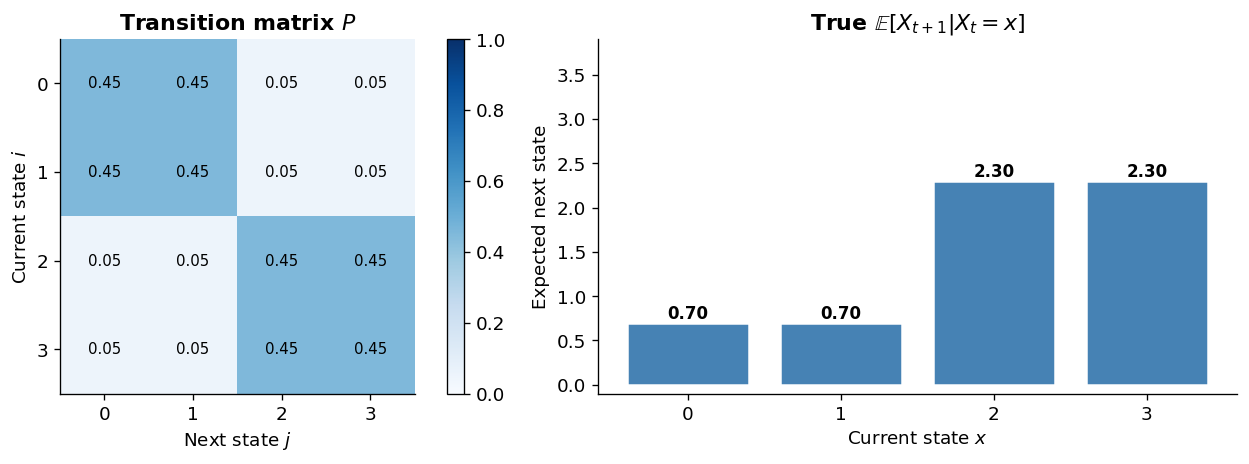

In [307]:
def plot_chain_overview(P):
    N  = P.shape[0]
    ce = true_conditional_expectation(P)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    im = axes[0].imshow(P, cmap='Blues', vmin=0, vmax=1)
    axes[0].set_title('Transition matrix $P$', fontweight='bold')
    axes[0].set_xlabel('Next state $j$')
    axes[0].set_ylabel('Current state $i$')
    axes[0].set_xticks(range(N)); axes[0].set_yticks(range(N))
    plt.colorbar(im, ax=axes[0], fraction=0.046)
    for i in range(N):
        for j in range(N):
            axes[0].text(j, i, f'{P[i,j]:.2f}', ha='center', va='center',
                         color='white' if P[i,j] > 0.5 else 'black', fontsize=9)

    axes[1].bar(range(N), ce, color='steelblue', edgecolor='white', linewidth=1.5)
    axes[1].set_title('True $\mathbb{E}[X_{t+1} | X_t = x]$', fontweight='bold')
    axes[1].set_xlabel('Current state $x$')
    axes[1].set_ylabel('Expected next state')
    axes[1].set_xticks(range(N))
    axes[1].set_ylim(-0.1, N - 0.1)
    for x, v in enumerate(ce):
        axes[1].text(x, v + 0.05, f'{v:.2f}', ha='center', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()


plot_chain_overview(P_TRUE)

---
## Test Run

In [308]:
# Trajectory & split 
T          = 3000
TRAIN_FRAC = 0.80
VAL_FRAC   = 0.10

# Repetitions
BASE_SEED = 69

Train: 2400  Val: 300  Test: 300
State frequencies: {0: 586, 1: 605, 2: 586, 3: 623}


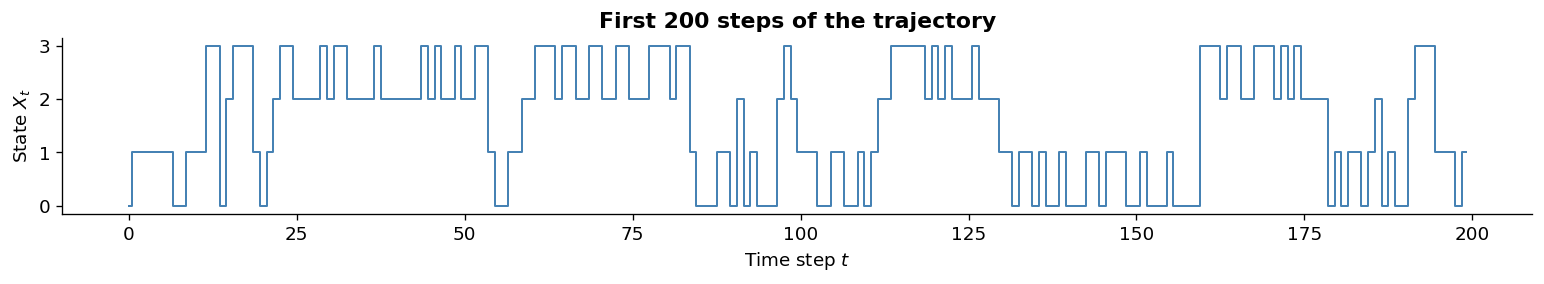

In [309]:
rng = np.random.default_rng(BASE_SEED)
X   = generate_trajectory(P_TRUE, T, rng)
X_train, X_val, X_test = split_trajectory(X, TRAIN_FRAC, VAL_FRAC)

print(f'Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}')
print(f'State frequencies: { {s: int(np.sum(X_train==s)) for s in range(N_STATES)} }')

# Quick plot of first 200 steps
fig, ax = plt.subplots(figsize=(13, 2.5))
ax.step(range(200), X[:200], where='mid', color='steelblue', linewidth=1.2)
ax.set_xlabel('Time step $t$')
ax.set_ylabel('State $X_t$')
ax.set_yticks(range(N_STATES))
ax.set_title('First 200 steps of the trajectory', fontweight='bold')
plt.tight_layout()
plt.show()

In [310]:
# Fit Monte Carlo
mc = MonteCarloCE(N_STATES).fit(X_train)

# compare against true conditional expectation
ce_true = true_conditional_expectation(P_TRUE)

print('Monte Carlo estimates vs truth:')
for s in range(N_STATES):
    print(f'  State {s}: visits={int(mc.counts[s]):4d}  '
          f'estimate={mc.estimates[s]:.4f}  true={ce_true[s]:.4f}  '
          f'|error|={abs(mc.estimates[s]-ce_true[s]):.4f}')

Monte Carlo estimates vs truth:
  State 0: visits= 586  estimate=0.7065  true=0.7000  |error|=0.0065
  State 1: visits= 605  estimate=0.6959  true=0.7000  |error|=0.0041
  State 2: visits= 586  estimate=2.3413  true=2.3000  |error|=0.0413
  State 3: visits= 622  estimate=2.3135  true=2.3000  |error|=0.0135


In [311]:
# Kernel VAR hyperparameters
# Small sigma (< 1)  -> nearly Kronecker delta     -> approaches MC
# Large sigma (>> 1) -> all states equally similar -> heavy smoothing
SIGMA_GRID  = np.array([0.1, 0.5, 1.0, 5.0, 20.0, 100.0, 1000.0]) 
LAMBDA_GRID = np.logspace(-4, 0, 6) 

In [312]:
#Tune and fit Kernel VAR (one-hot)

best_sigma, best_lam, best_val_mpe, grid_results = tune_kernel_var_onehot(X_train, X_val, N_STATES, SIGMA_GRID, LAMBDA_GRID)
print(f'Best sigma={best_sigma}, lam={best_lam:.0e} ->  val MPE={best_val_mpe:.4f}')

Best sigma=5.0, lam=6e-04 ->  val MPE=0.6243


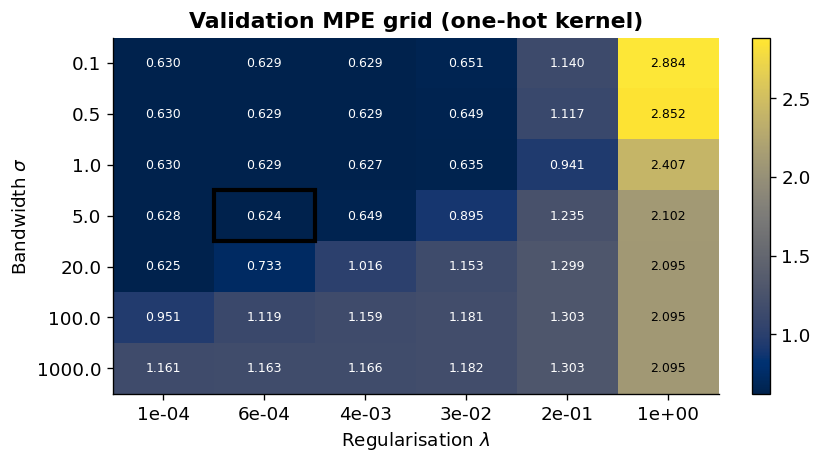

In [ ]:
# Plot the grid
fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(grid_results, cmap='RdYlGn_r', aspect='auto')
ax.set_xticks(range(len(LAMBDA_GRID)))
ax.set_xticklabels([f'{l:.0e}' for l in LAMBDA_GRID])
ax.set_yticks(range(len(SIGMA_GRID)))
ax.set_yticklabels([str(s) for s in SIGMA_GRID])
ax.set_xlabel('Regularisation $\lambda$')
ax.set_ylabel('Bandwidth $\sigma$')
ax.set_title('Validation MPE grid (one-hot kernel)', fontweight='bold')
plt.colorbar(im, ax=ax, fraction=0.046)
for i in range(len(SIGMA_GRID)):
    for j in range(len(LAMBDA_GRID)):
        ax.text(j, i, f'{grid_results[i,j]:.3f}', ha='center', va='center',
                fontsize=7.5,
                color='white' if grid_results[i,j] > np.nanmean(grid_results) else 'black')
bi = int(np.argmin(np.abs(SIGMA_GRID - best_sigma)))
bj = int(np.argmin(np.abs(LAMBDA_GRID - best_lam)))
ax.add_patch(plt.Rectangle((bj-0.5, bi-0.5), 1, 1,
             fill=False, edgecolor='blue', linewidth=2.5))
plt.tight_layout()
plt.show()

kvar = KernelVAROneHot(N_STATES, sigma=best_sigma, lam=best_lam).fit(X_train)

In [314]:
# Test set comparison
mc_test   = mc.mpe(X_test)
kvar_test = kvar.mpe(X_test)
oracle    = oracle_error(P_TRUE, X_test)

print('='*55)
print(f'  Oracle (true CE)  : {oracle:.4f}  ← irreducible floor')
print(f'  Monte Carlo       : {mc_test:.4f}  (+{mc_test-oracle:.4f})')
print(f'  Kernel VAR (1-hot): {kvar_test:.4f}  (+{kvar_test-oracle:.4f})')
print('='*55)
winner = 'Monte Carlo' if mc_test < kvar_test else 'Kernel VAR (1-hot)'
print(f'{winner} wins by {abs(mc_test - kvar_test):.4f}')

  Oracle (true CE)  : 0.4846  ← irreducible floor
  Monte Carlo       : 0.4850  (+0.0003)
  Kernel VAR (1-hot): 0.4895  (+0.0048)
Monte Carlo wins by 0.0045


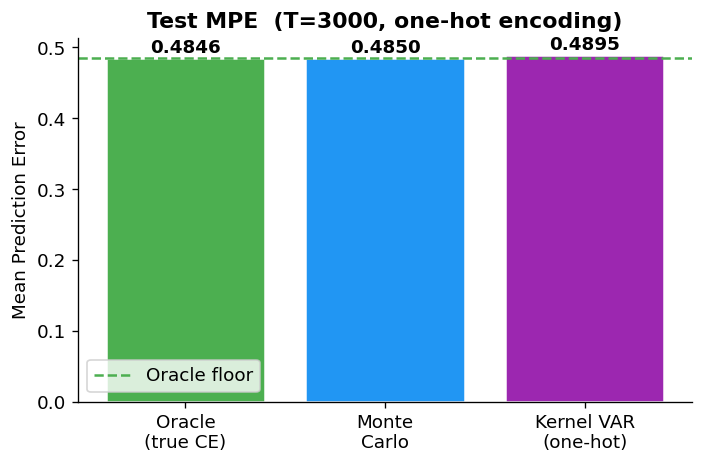

In [315]:
fig, ax = plt.subplots(figsize=(6, 4))
methods = ['Oracle\n(true CE)', 'Monte\nCarlo', 'Kernel VAR\n(one-hot)']
values  = [oracle, mc_test, kvar_test]
colors  = ['#4CAF50', '#2196F3', '#9C27B0']
bars    = ax.bar(methods, values, color=colors, edgecolor='white', linewidth=1.5)
ax.axhline(oracle, color='#4CAF50', linestyle='--', linewidth=1.5, label='Oracle floor')
ax.set_ylabel('Mean Prediction Error')
ax.set_title(f'Test MPE  (T={T}, one-hot encoding)', fontweight='bold')
ax.legend()
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.002,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

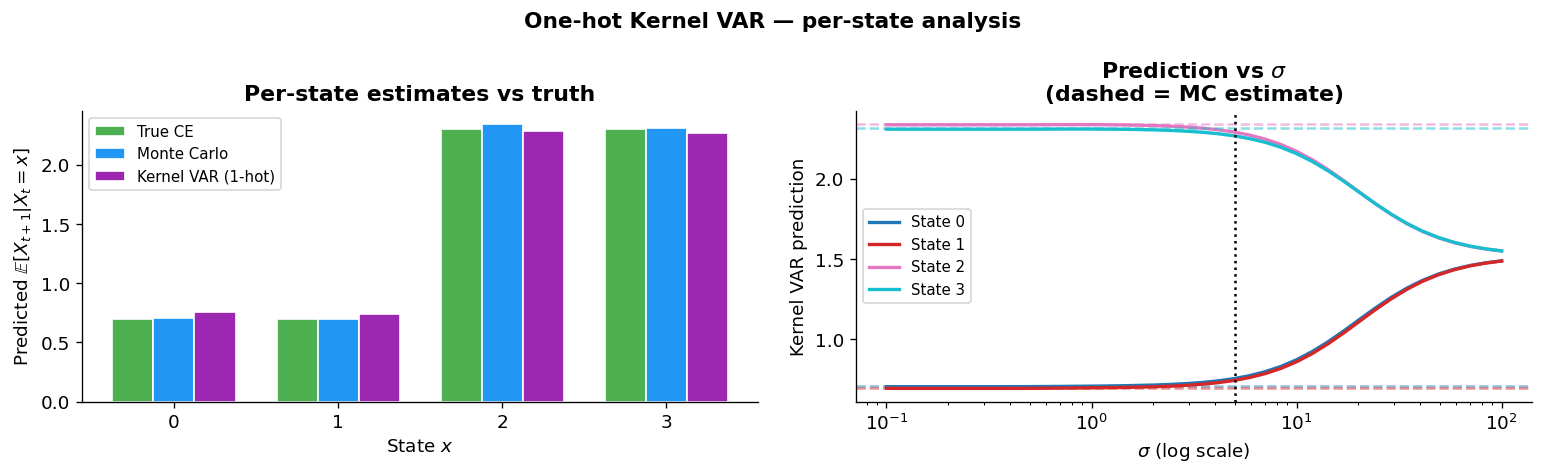

In [316]:
# Per-state predictions
states       = np.arange(N_STATES)
mc_preds     = np.array([mc.predict(x) for x in states])
kv_preds     = np.array([kvar.predict(x) for x in states])
ce_true_vals = true_conditional_expectation(P_TRUE)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: bar chart per state
width = 0.25
axes[0].bar(states - width, ce_true_vals, width=width, label='True CE',   color='#4CAF50', edgecolor='white')
axes[0].bar(states,         mc_preds,     width=width, label='Monte Carlo', color='#2196F3', edgecolor='white')
axes[0].bar(states + width, kv_preds,     width=width, label='Kernel VAR (1-hot)', color='#9C27B0', edgecolor='white')
axes[0].set_xlabel('State $x$')
axes[0].set_ylabel('Predicted $\mathbb{E}[X_{t+1}|X_t=x]$')
axes[0].set_title('Per-state estimates vs truth', fontweight='bold')
axes[0].set_xticks(states)
axes[0].legend(fontsize=9)

# Right: how predictions vary with sigma (fixing best lambda)
sigma_range = np.logspace(-1, 2, 40)
preds_by_sigma = np.zeros((len(sigma_range), N_STATES))
for k, s in enumerate(sigma_range):
    m = KernelVAROneHot(N_STATES, sigma=s, lam=best_lam).fit(X_train)
    preds_by_sigma[k] = [m.predict(x) for x in states]

colors_states = plt.cm.tab10(np.linspace(0, 1, N_STATES))
for x in states:
    axes[1].plot(sigma_range, preds_by_sigma[:, x],
                 label=f'State {x}', color=colors_states[x], linewidth=2)
    axes[1].axhline(mc_preds[x], color=colors_states[x],
                    linestyle='--', alpha=0.5)
axes[1].set_xscale('log')
axes[1].set_xlabel('$\sigma$ (log scale)')
axes[1].set_ylabel('Kernel VAR prediction')
axes[1].set_title('Prediction vs $\sigma$\n(dashed = MC estimate)', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].axvline(best_sigma, color='black', linestyle=':', linewidth=1.5,
                label=f'Best $\sigma$={best_sigma}')

plt.suptitle('One-hot Kernel VAR — per-state analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Multiple runs

In [317]:
N_RUNS    = 20

In [318]:
mc_mpes   = []
kvar_mpes = []
oracle_mpes = []

for run in range(N_RUNS):
    rng_r = np.random.default_rng(BASE_SEED + run)
    X_r   = generate_trajectory(P_TRUE, T, rng_r)
    tr, va, te = split_trajectory(X_r)

    mc_r = MonteCarloCE(N_STATES).fit(tr)
    bs, bl, _, _ = tune_kernel_var_onehot(tr, va, N_STATES, SIGMA_GRID, LAMBDA_GRID)
    kv_r = KernelVAROneHot(N_STATES, sigma=bs, lam=bl).fit(tr)

    mc_mpes.append(mc_r.mpe(te))
    kvar_mpes.append(kv_r.mpe(te))
    oracle_mpes.append(oracle_error(P_TRUE, te))

    if (run+1) % 5 == 0:
        print(f'  Run {run+1}/{N_RUNS} done')

mc_arr     = np.array(mc_mpes)
kvar_arr   = np.array(kvar_mpes)
oracle_arr = np.array(oracle_mpes)

print(f'\nResults over {N_RUNS} runs:')
print(f'  Oracle     : {oracle_arr.mean():.4f} ± {oracle_arr.std():.4f}')
print(f'  Monte Carlo: {mc_arr.mean():.4f} ± {mc_arr.std():.4f}')
print(f'  Kernel VAR : {kvar_arr.mean():.4f} ± {kvar_arr.std():.4f}')
mc_wins = int(np.sum(mc_arr < kvar_arr))
print(f'  MC wins: {mc_wins}/{N_RUNS}  |  KV wins: {N_RUNS-mc_wins}/{N_RUNS}')

  Run 5/20 done
  Run 10/20 done
  Run 15/20 done
  Run 20/20 done

Results over 20 runs:
  Oracle     : 0.5983 ± 0.0629
  Monte Carlo: 0.5982 ± 0.0621
  Kernel VAR : 0.6018 ± 0.0634
  MC wins: 11/20  |  KV wins: 9/20


---
## Effect of Trajectory Length $T$

With one-hot encoding and small $\sigma$, Kernel VAR approaches Monte Carlo.
The interesting question is: **does the ability to tune $\sigma$ help at small $T$?**
When data is scarce, a larger $\sigma$ shares information across states,
which could outperform pure MC that treats each state independently.

In [319]:
# T-sweep
T_VALUES  = [10, 20, 30, 50, 70, 100, 200, 300, 500, 700, 1000, 2000, 3000]

In [320]:
sweep = {T_val: {'mc': [], 'kvar': [], 'oracle': []} for T_val in T_VALUES}
SWEEP_RUNS = max(5, N_RUNS // 2)

for T_val in T_VALUES:
    print(f'T={T_val}...', end=' ', flush=True)
    for run in range(SWEEP_RUNS):
        rng_s = np.random.default_rng(BASE_SEED + 200 + run)
        X_s   = generate_trajectory(P_TRUE, T_val, rng_s)
        tr, va, te = split_trajectory(X_s)
        if len(te) < 2: continue

        mc_s = MonteCarloCE(N_STATES).fit(tr)
        bs, bl, _, _ = tune_kernel_var_onehot(tr, va, N_STATES, SIGMA_GRID, LAMBDA_GRID)
        kv_s = KernelVAROneHot(N_STATES, sigma=bs, lam=bl).fit(tr)

        sweep[T_val]['mc'].append(mc_s.mpe(te))
        sweep[T_val]['kvar'].append(kv_s.mpe(te))
        sweep[T_val]['oracle'].append(oracle_error(P_TRUE, te))

    print(f"MC={np.nanmean(sweep[T_val]['mc']):.4f}  "
          f"KV={np.nanmean(sweep[T_val]['kvar']):.4f}")

T=10... MC=nan  KV=nan
T=20... 

MC=0.2748  KV=0.5502
T=30... MC=0.3495  KV=0.9738
T=50... MC=0.5300  KV=0.6039
T=70... MC=0.9208  KV=1.1002
T=100... MC=0.5640  KV=0.5578
T=200... MC=0.5223  KV=0.8301
T=300... MC=0.5849  KV=0.6602
T=500... MC=0.5735  KV=0.5796
T=700... MC=0.5675  KV=0.5853
T=1000... MC=0.6457  KV=0.6440
T=2000... MC=0.5995  KV=0.6034
T=3000... MC=0.5962  KV=0.5970


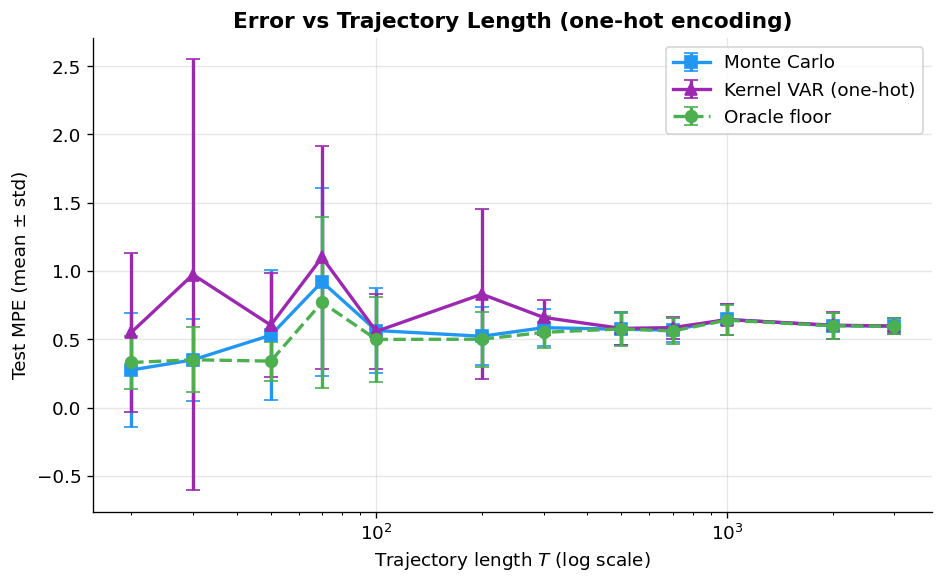

In [321]:
mc_means   = [np.nanmean(sweep[T_val]['mc'])   for T_val in T_VALUES]
kvar_means = [np.nanmean(sweep[T_val]['kvar'])  for T_val in T_VALUES]

mc_stds    = [np.nanstd (sweep[T_val]['mc'])    for T_val in T_VALUES]
kvar_stds  = [np.nanstd (sweep[T_val]['kvar'])  for T_val in T_VALUES]

oracle_means = [np.nanmean(sweep[T_val]['oracle']) for T_val in T_VALUES]
oracle_stds  = [np.nanstd (sweep[T_val]['oracle']) for T_val in T_VALUES]



fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(T_VALUES, mc_means,   yerr=mc_stds,   fmt='s-', color='#2196F3',
            label='Monte Carlo', capsize=4, linewidth=2, markersize=7)
ax.errorbar(T_VALUES, kvar_means, yerr=kvar_stds, fmt='^-', color='#9C27B0',
            label='Kernel VAR (one-hot)', capsize=4, linewidth=2, markersize=7)
ax.errorbar(T_VALUES, oracle_means, yerr=oracle_stds, fmt='o--', color='#4CAF50',
            label='Oracle floor', capsize=4, linewidth=2, markersize=7)
ax.set_xscale('log')
ax.set_xlabel('Trajectory length $T$ (log scale)')
ax.set_ylabel('Test MPE (mean ± std)')
ax.set_title('Error vs Trajectory Length (one-hot encoding)', fontweight='bold', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Effect of Noise Variance

We **parameterise noise** with a single value $\epsilon \in [0, 1]$
that interpolates between a low-noise and a high-noise chain:

$$P^{(\epsilon)}_{x,j} = (1 - \epsilon) \cdot P^{\text{base}}_{x,j} + \epsilon \cdot \frac{1}{N}$$

- $\epsilon = 0$: original chain, **lowest noise**
- $\epsilon = 1$: fully uniform chain, **maximum noise** (next state is completely random)

In [322]:
# Noise sweep configuration 
EPSILON_VALUES = [0.0, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0]      # noise levels to test
NOISE_BASE     = P_TRUE                           # base chain to add noise to
T_NOISE        = T                                        # trajectory length for noise sweep
NOISE_RUNS     = max(5, N_RUNS // 2)                      # runs per noise level

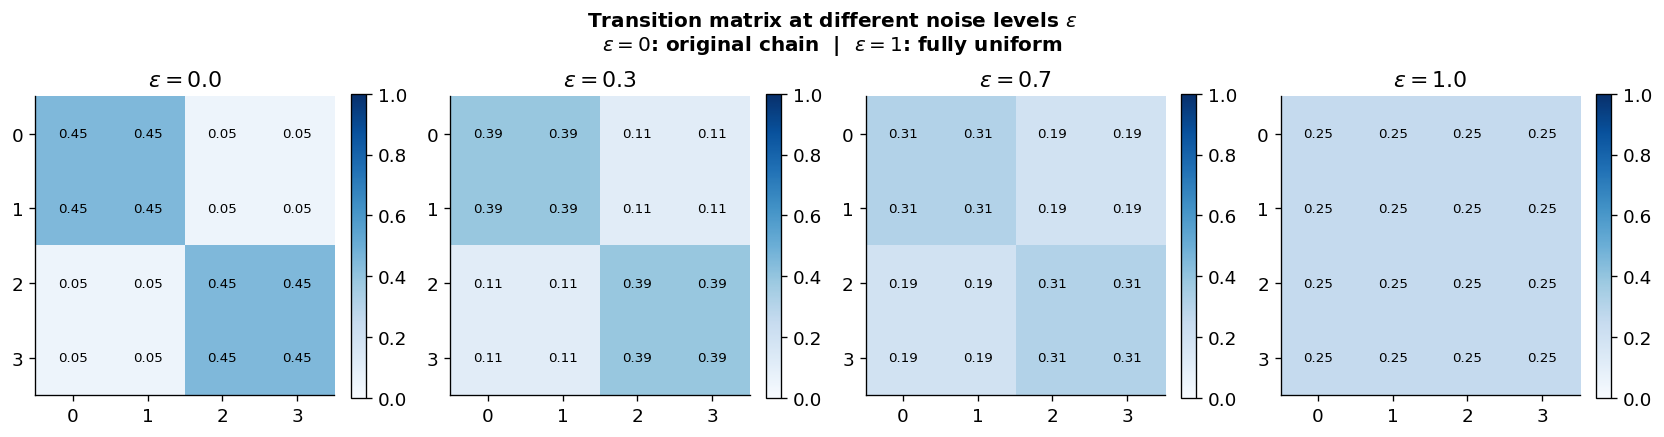

In [323]:
def make_noisy_chain(P_base, epsilon):
    """
    Interpolate between P_base (epsilon=0) and uniform (epsilon=1).
    P_noisy[x,j] = (1-epsilon)*P_base[x,j] + epsilon*(1/N)
    """
    N       = P_base.shape[0]
    P_noisy = (1 - epsilon) * P_base + epsilon * np.ones((N, N)) / N
    assert np.allclose(P_noisy.sum(axis=1), 1.0)
    return P_noisy


# Visualise how the chain changes with epsilon 
epsilons_to_show = [0.0, 0.3, 0.7, 1.0]
fig, axes = plt.subplots(1, len(epsilons_to_show), figsize=(14, 3.5))

for ax, eps in zip(axes, epsilons_to_show):
    P_eps = make_noisy_chain(NOISE_BASE, eps)
    n_eps = P_eps.shape[0]
    im    = ax.imshow(P_eps, cmap='Blues', vmin=0, vmax=1)
    ax.set_title(f'$\\epsilon={eps}$', fontweight='bold')
    ax.set_xticks(range(n_eps)); ax.set_yticks(range(n_eps))
    plt.colorbar(im, ax=ax, fraction=0.046)
    for i in range(n_eps):
        for j in range(n_eps):
            ax.text(j, i, f'{P_eps[i,j]:.2f}', ha='center', va='center',
                    color='white' if P_eps[i,j] > 0.5 else 'black', fontsize=8)

fig.suptitle('Transition matrix at different noise levels $\\epsilon$\n'
             '$\\epsilon=0$: original chain  |  $\\epsilon=1$: fully uniform',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [324]:
# Run the noise sweep 
noise_sweep = {eps: {'mc': [], 'kvar': [], 'oracle': []} for eps in EPSILON_VALUES}

for eps in EPSILON_VALUES:
    P_eps = make_noisy_chain(NOISE_BASE, eps)
    print(f'epsilon={eps:.1f}...', end=' ', flush=True)

    for run in range(NOISE_RUNS):
        rng_n = np.random.default_rng(BASE_SEED + 300 + run)
        X_n   = generate_trajectory(P_eps, T_NOISE, rng_n)
        tr, va, te = split_trajectory(X_n)
        if len(te) < 2: continue

        mc_n = MonteCarloCE(N_STATES).fit(tr)
        bs, bl, _, _ = tune_kernel_var_onehot(tr, va, N_STATES, SIGMA_GRID, LAMBDA_GRID)
        kv_n = KernelVAROneHot(N_STATES, sigma=bs, lam=bl).fit(tr)

        noise_sweep[eps]['mc'].append(mc_n.mpe(te))
        noise_sweep[eps]['kvar'].append(kv_n.mpe(te))
        noise_sweep[eps]['oracle'].append(oracle_error(P_eps, te))

    mc_mean  = np.nanmean(noise_sweep[eps]['mc'])
    kv_mean  = np.nanmean(noise_sweep[eps]['kvar'])
    ora_mean = np.nanmean(noise_sweep[eps]['oracle'])
    print(f'Oracle={ora_mean:.4f}  MC={mc_mean:.4f}  KV={kv_mean:.4f}')

epsilon=0.0... Oracle=0.5823  MC=0.5826  KV=0.5877
epsilon=0.1... Oracle=0.7054  MC=0.7042  KV=0.7102
epsilon=0.2... Oracle=0.8181  MC=0.8172  KV=0.8243
epsilon=0.4... Oracle=1.0121  MC=1.0128  KV=1.0217
epsilon=0.6... Oracle=1.1434  MC=1.1457  KV=1.1578
epsilon=0.8... Oracle=1.2399  MC=1.2441  KV=1.2489
epsilon=1.0... Oracle=1.2587  MC=1.2614  KV=1.2639


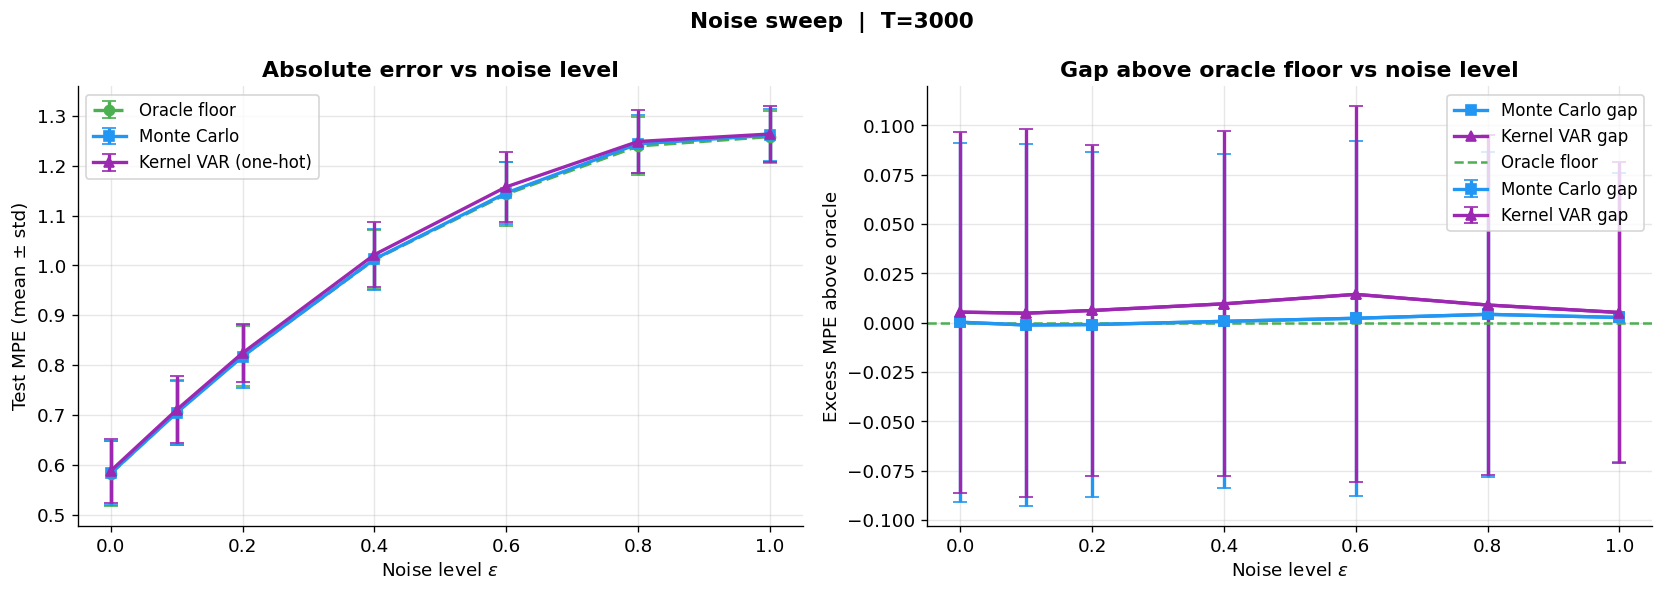

In [325]:
# Plot noise sweep results
mc_means     = [np.nanmean(noise_sweep[e]['mc'])     for e in EPSILON_VALUES]
mc_stds      = [np.nanstd (noise_sweep[e]['mc'])     for e in EPSILON_VALUES]

kvar_means   = [np.nanmean(noise_sweep[e]['kvar'])   for e in EPSILON_VALUES]
kvar_stds    = [np.nanstd (noise_sweep[e]['kvar'])   for e in EPSILON_VALUES]

oracle_means = [np.nanmean(noise_sweep[e]['oracle']) for e in EPSILON_VALUES]
oracle_stds  = [np.nanstd (noise_sweep[e]['oracle']) for e in EPSILON_VALUES]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: absolute MPE vs epsilon
axes[0].errorbar(EPSILON_VALUES, oracle_means, yerr=oracle_stds,
                 fmt='o--', color='#4CAF50', label='Oracle floor',
                 capsize=4, linewidth=2, markersize=6)
axes[0].errorbar(EPSILON_VALUES, mc_means,   yerr=mc_stds,
                 fmt='s-', color='#2196F3', label='Monte Carlo',
                 capsize=4, linewidth=2, markersize=6)
axes[0].errorbar(EPSILON_VALUES, kvar_means, yerr=kvar_stds,
                 fmt='^-', color='#9C27B0', label='Kernel VAR (one-hot)',
                 capsize=4, linewidth=2, markersize=6)
axes[0].set_xlabel('Noise level $\\epsilon$')
axes[0].set_ylabel('Test MPE (mean ± std)')
axes[0].set_title('Absolute error vs noise level', fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Right: gap above oracle floor (how much worse than best possible)
mc_gap   = np.array(mc_means)   - np.array(oracle_means)
kvar_gap = np.array(kvar_means) - np.array(oracle_means)

axes[1].plot(EPSILON_VALUES, mc_gap,   's-', color='#2196F3',
             label='Monte Carlo gap', linewidth=2, markersize=6)
axes[1].plot(EPSILON_VALUES, kvar_gap, '^-', color='#9C27B0',
             label='Kernel VAR gap', linewidth=2, markersize=6)

mc_gap_std   = np.sqrt(np.array(mc_stds)**2   + np.array(oracle_stds)**2)
kvar_gap_std = np.sqrt(np.array(kvar_stds)**2 + np.array(oracle_stds)**2)

axes[1].errorbar(EPSILON_VALUES, mc_gap,   yerr=mc_gap_std,   fmt='s-', color='#2196F3',
                 label='Monte Carlo gap', capsize=4, linewidth=2, markersize=6)
axes[1].errorbar(EPSILON_VALUES, kvar_gap, yerr=kvar_gap_std, fmt='^-', color='#9C27B0',
                 label='Kernel VAR gap', capsize=4, linewidth=2, markersize=6)

axes[1].axhline(0, color='#4CAF50', linestyle='--', linewidth=1.5, label='Oracle floor')
axes[1].set_xlabel('Noise level $\\epsilon$')
axes[1].set_ylabel('Excess MPE above oracle')
axes[1].set_title('Gap above oracle floor vs noise level', fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Noise sweep  |  T={T_NOISE}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()